# 03 - Entrenamiento de Transformer para sentimiento general

## Objetivo

Este notebook entrena un modelo transformer para clasificación de sentimiento general sobre reviews gastronómicas del corpus Yelp.

El objetivo es comparar un modelo moderno de NLP frente al baseline clásico obtenido en el Notebook 01:

- Majority Baseline
- TF-IDF + Logistic Regression
- TF-IDF + Logistic Regression Balanced
- Transformer fine-tuned

Este modelo sigue siendo un módulo auxiliar. No representa todavía el sentimiento final por plato, pero permite evaluar si un transformer aporta mejora frente a modelos clásicos sobre reviews gastronómicas.


In [1]:
# ============================================================
# 01. Instalación de dependencias
# ============================================================

!pip -q install pandas numpy scikit-learn matplotlib tqdm pyarrow
!pip -q install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
# ============================================================
# 02. Imports y configuración
# ============================================================

from pathlib import Path
import json
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [3]:
# ============================================================
# 03. Entorno robusto + descarga automática de archivos desde Google Drive
# ============================================================

from pathlib import Path
import shutil
import zipfile
import re
import os

# ------------------------------------------------------------
# 1. Configuración general
# ------------------------------------------------------------

USE_DRIVE = True

if USE_DRIVE:
    try:
        from google.colab import drive

        # Limpieza preventiva del punto de montaje
        !fusermount -u /content/drive 2>/dev/null || true
        !rm -rf /content/drive

        drive.mount("/content/drive", force_remount=True, timeout_ms=120000)

        PROJECT_DIR = Path("/content/drive/MyDrive/hidden_gems_ai")
        DATA_DIR = PROJECT_DIR / "data"

        PROJECT_DIR.mkdir(parents=True, exist_ok=True)
        DATA_DIR.mkdir(parents=True, exist_ok=True)

        print("Google Drive montado correctamente.")

    except Exception as e:
        print("No se ha podido montar Google Drive.")
        print("Error:", e)
        print("Se usará almacenamiento temporal de Colab en /content/hidden_gems_ai")

        USE_DRIVE = False
        PROJECT_DIR = Path("/content/hidden_gems_ai")
        DATA_DIR = PROJECT_DIR / "data"

        PROJECT_DIR.mkdir(parents=True, exist_ok=True)
        DATA_DIR.mkdir(parents=True, exist_ok=True)

else:
    PROJECT_DIR = Path("/content/hidden_gems_ai")
    DATA_DIR = PROJECT_DIR / "data"

    PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)


OUTPUT_DIR = PROJECT_DIR / "outputs" / "sentiment_review_transformer"
MODEL_DIR = OUTPUT_DIR / "model"
METRICS_DIR = OUTPUT_DIR / "metrics"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
TMP_DIR = PROJECT_DIR / "tmp"

for path in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, METRICS_DIR, PREDICTIONS_DIR, TMP_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


# ------------------------------------------------------------
# 2. Funciones para descargar desde Google Drive
# ------------------------------------------------------------

def extract_drive_file_id(file_id_or_url: str) -> str:
    """
    Acepta un file_id directamente o un enlace de Google Drive
    y devuelve el file_id.
    """

    file_id_or_url = str(file_id_or_url).strip()

    # Caso 1: ya parece un file_id
    if "drive.google.com" not in file_id_or_url:
        return file_id_or_url

    # Caso 2: enlaces tipo /file/d/<ID>/view
    match = re.search(r"/file/d/([^/]+)", file_id_or_url)
    if match:
        return match.group(1)

    # Caso 3: enlaces tipo ?id=<ID>
    match = re.search(r"[?&]id=([^&]+)", file_id_or_url)
    if match:
        return match.group(1)

    raise ValueError(
        "No se pudo extraer el file_id del enlace de Google Drive:\n"
        f"{file_id_or_url}"
    )


def download_file_from_drive(file_id_or_url: str, output_path: Path, description: str = "archivo"):
    """
    Descarga un archivo desde Google Drive usando gdown.
    Si el archivo ya existe, no lo vuelve a descargar.
    """

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"{description} ya existe, no se descarga de nuevo:")
        print(output_path)
        return output_path

    try:
        import gdown
    except ImportError:
        print("Instalando gdown...")
        !pip -q install gdown
        import gdown

    file_id = extract_drive_file_id(file_id_or_url)

    print(f"Descargando {description} desde Google Drive...")
    print("Destino:", output_path)

    gdown.download(
        id=file_id,
        output=str(output_path),
        quiet=False
    )

    if not output_path.exists() or output_path.stat().st_size == 0:
        raise FileNotFoundError(
            f"La descarga de {description} no se completó correctamente:\n"
            f"{output_path}"
        )

    print(f"Descarga completada: {output_path}")
    return output_path


def ensure_required_files(files_config: list[dict]):
    """
    Garantiza que los archivos necesarios existen.
    Si no existen, los descarga desde Google Drive.
    """

    for file_cfg in files_config:
        name = file_cfg["name"]
        output_path = Path(file_cfg["output_path"])
        drive_source = file_cfg.get("drive_source")

        if output_path.exists() and output_path.stat().st_size > 0:
            print(f"OK - {name} encontrado:")
            print(output_path)
            continue

        if not drive_source:
            raise FileNotFoundError(
                f"No se encontró {name} en:\n{output_path}\n\n"
                "Añade un enlace o file_id en drive_source para descargarlo automáticamente."
            )

        download_file_from_drive(
            file_id_or_url=drive_source,
            output_path=output_path,
            description=name
        )


# ------------------------------------------------------------
# 3. Archivos necesarios para este notebook
# ------------------------------------------------------------

RAW_CORPUS_PATH = DATA_DIR / "yelp_food_reviews_corpus_sample_100k_lines.jsonl"

PREPARED_DATASET_PATH = (
    PROJECT_DIR
    / "outputs"
    / "sentiment_review"
    / "yelp_sentiment_prepared_dataset.parquet"
)

# IMPORTANTE:
# Sustituye los valores de drive_source por tus enlaces de Google Drive
# o por el file_id directamente.
#
# Si tienes el parquet del Notebook 01, es mejor descargar ese.
# Si no lo tienes, basta con descargar el JSONL original.

FILES_TO_DOWNLOAD = [
    {
        "name": "Corpus Yelp NLP JSONL",
        "output_path": RAW_CORPUS_PATH,
        "drive_source": "https://drive.google.com/file/d/1Phb9Ut5j4orZRVkwI9eEPNTBKkkriYs3/view?usp=sharing"
    },

    # Opcional: si has subido el parquet preparado del Notebook 01,
    # descomenta este bloque y pega su enlace.
     {
         "name": "Dataset preparado Parquet",
         "output_path": PREPARED_DATASET_PATH,
         "drive_source": "https://drive.google.com/file/d/1-FvSUMnAekt39ODngsmosDjuE7-n-XjU/view?usp=sharing"
     },
]

ensure_required_files(FILES_TO_DOWNLOAD)

print("\nArchivos listos para el notebook:")
print("RAW_CORPUS_PATH:", RAW_CORPUS_PATH, "->", RAW_CORPUS_PATH.exists())
print("PREPARED_DATASET_PATH:", PREPARED_DATASET_PATH, "->", PREPARED_DATASET_PATH.exists())

No se ha podido montar Google Drive.
Error: Error: credential propagation was unsuccessful
Se usará almacenamiento temporal de Colab en /content/hidden_gems_ai
PROJECT_DIR: /content/hidden_gems_ai
DATA_DIR: /content/hidden_gems_ai/data
OUTPUT_DIR: /content/hidden_gems_ai/outputs/sentiment_review_transformer
Descargando Corpus Yelp NLP JSONL desde Google Drive...
Destino: /content/hidden_gems_ai/data/yelp_food_reviews_corpus_sample_100k_lines.jsonl


Downloading...
From (original): https://drive.google.com/uc?id=1Phb9Ut5j4orZRVkwI9eEPNTBKkkriYs3
From (redirected): https://drive.google.com/uc?id=1Phb9Ut5j4orZRVkwI9eEPNTBKkkriYs3&confirm=t&uuid=fcc251ec-e9f1-41bc-9648-36cac72e245a
To: /content/hidden_gems_ai/data/yelp_food_reviews_corpus_sample_100k_lines.jsonl
100%|██████████| 186M/186M [00:02<00:00, 86.8MB/s]


Descarga completada: /content/hidden_gems_ai/data/yelp_food_reviews_corpus_sample_100k_lines.jsonl
Descargando Dataset preparado Parquet desde Google Drive...
Destino: /content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_prepared_dataset.parquet


Downloading...
From: https://drive.google.com/uc?id=1-FvSUMnAekt39ODngsmosDjuE7-n-XjU
To: /content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_prepared_dataset.parquet
100%|██████████| 30.3M/30.3M [00:00<00:00, 50.6MB/s]

Descarga completada: /content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_prepared_dataset.parquet

Archivos listos para el notebook:
RAW_CORPUS_PATH: /content/hidden_gems_ai/data/yelp_food_reviews_corpus_sample_100k_lines.jsonl -> True
PREPARED_DATASET_PATH: /content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_prepared_dataset.parquet -> True


In [4]:
# ============================================================
# 04. Cargar dataset preparado
# ============================================================

PREPARED_DATASET_PATH = PROJECT_DIR / "outputs" / "sentiment_review" / "yelp_sentiment_prepared_dataset.parquet"
RAW_CORPUS_PATH = DATA_DIR / "yelp_food_reviews_corpus_sample_100k_lines.jsonl"

if PREPARED_DATASET_PATH.exists():
    print("Cargando dataset preparado desde Notebook 01:")
    print(PREPARED_DATASET_PATH)
    df = pd.read_parquet(PREPARED_DATASET_PATH)

else:
    print("No se ha encontrado el parquet preparado. Se cargará el JSONL original.")

    if not RAW_CORPUS_PATH.exists():
        raise FileNotFoundError(
            f"No se encontró ni el parquet preparado ni el corpus original:\n"
            f"- {PREPARED_DATASET_PATH}\n"
            f"- {RAW_CORPUS_PATH}"
        )

    records = []
    with RAW_CORPUS_PATH.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    df_raw = pd.DataFrame(records)

    df = pd.DataFrame({
        "review_id": df_raw["source_review_id"].astype(str),
        "business_id": df_raw["source_business_id"].astype(str),
        "text": df_raw["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip(),
        "model_text": df_raw["text_normalized"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip(),
        "rating_value": pd.to_numeric(df_raw["rating_value"], errors="coerce"),
        "sentiment_label": df_raw["sentiment_label_from_rating"].astype(str).str.lower().str.strip(),
        "split": df_raw["corpus_split"].astype(str).str.lower().str.strip(),
    })

print("Shape:", df.shape)
display(df.head(3))

print("\nColumnas:")
print(df.columns.tolist())

Cargando dataset preparado desde Notebook 01:
/content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_prepared_dataset.parquet
Shape: (79270, 9)


,review_id,business_id,text,text_length_chars,rating_value,sentiment_label,language,review_date,split
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is go...",511,3.0,neutral,en,2018-07-07 22:09:11,train
1,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive...",339,3.0,neutral,en,2014-02-05 20:30:30,train
2,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",235,5.0,positive,en,2015-01-04 00:01:03,train



Columnas:
['review_id', 'business_id', 'text', 'text_length_chars', 'rating_value', 'sentiment_label', 'language', 'review_date', 'split']


In [5]:
# ============================================================
# 05. Normalizar columnas para entrenamiento
# ============================================================

if "model_text" not in df.columns:
    df["model_text"] = df["text"]

df["model_text"] = (
    df["model_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["sentiment_label"] = (
    df["sentiment_label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["split"] = (
    df["split"]
    .astype(str)
    .str.lower()
    .str.strip()
)

valid_labels = ["negative", "neutral", "positive"]
valid_splits = ["train", "validation", "test"]

df = df[
    df["sentiment_label"].isin(valid_labels)
    & df["split"].isin(valid_splits)
    & df["model_text"].notna()
    & (df["model_text"].str.len() > 0)
].copy()

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

df["labels"] = df["sentiment_label"].map(label2id).astype(int)
df["text_length_chars"] = df["model_text"].str.len()

print("Shape final:", df.shape)

print("\nDistribución por split:")
display(df["split"].value_counts())

print("\nDistribución por sentimiento:")
display(df["sentiment_label"].value_counts())

print("\nSplit x sentimiento:")
display(pd.crosstab(df["split"], df["sentiment_label"]))

Shape final: (79270, 11)

Distribución por split:


,count
split,
train,63540
test,7881
validation,7849



Distribución por sentimiento:


,count
sentiment_label,
positive,54857
negative,14578
neutral,9835



Split x sentimiento:


sentiment_label,negative,neutral,positive
split,,,
test,1428,936,5517
train,11701,7894,43945
validation,1449,1005,5395


In [6]:
# ============================================================
# 06. Configuración de entrenamiento
# ============================================================

MODEL_CHECKPOINT = "distilbert-base-uncased"

MAX_LENGTH = 256
NUM_EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32

USE_CLASS_WEIGHTS = True

# Activa esto solo para probar que el notebook funciona rápido.
FAST_DEV_RUN = False

if FAST_DEV_RUN:
    print("FAST_DEV_RUN activado: se usará una muestra pequeña.")
    train_sample = df[df["split"] == "train"].groupby("sentiment_label", group_keys=False).sample(
        n=600,
        random_state=RANDOM_STATE
    )
    val_sample = df[df["split"] == "validation"].groupby("sentiment_label", group_keys=False).sample(
        n=150,
        random_state=RANDOM_STATE
    )
    test_sample = df[df["split"] == "test"].groupby("sentiment_label", group_keys=False).sample(
        n=150,
        random_state=RANDOM_STATE
    )
    df_train_ready = pd.concat([train_sample, val_sample, test_sample], ignore_index=True)
else:
    df_train_ready = df.copy()

print("Modelo:", MODEL_CHECKPOINT)
print("MAX_LENGTH:", MAX_LENGTH)
print("NUM_EPOCHS:", NUM_EPOCHS)
print("USE_CLASS_WEIGHTS:", USE_CLASS_WEIGHTS)
print("FAST_DEV_RUN:", FAST_DEV_RUN)

display(pd.crosstab(df_train_ready["split"], df_train_ready["sentiment_label"]))

Modelo: distilbert-base-uncased
MAX_LENGTH: 256
NUM_EPOCHS: 2
USE_CLASS_WEIGHTS: True
FAST_DEV_RUN: False


sentiment_label,negative,neutral,positive
split,,,
test,1428,936,5517
train,11701,7894,43945
validation,1449,1005,5395


In [7]:
# ============================================================
# 07. Crear DatasetDict
# ============================================================

hf_columns = ["model_text", "labels", "sentiment_label", "review_id", "business_id", "rating_value", "split"]

for col in hf_columns:
    if col not in df_train_ready.columns:
        df_train_ready[col] = None

train_pd = df_train_ready[df_train_ready["split"] == "train"][hf_columns].reset_index(drop=True)
val_pd = df_train_ready[df_train_ready["split"] == "validation"][hf_columns].reset_index(drop=True)
test_pd = df_train_ready[df_train_ready["split"] == "test"][hf_columns].reset_index(drop=True)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_pd, preserve_index=False),
    "validation": Dataset.from_pandas(val_pd, preserve_index=False),
    "test": Dataset.from_pandas(test_pd, preserve_index=False),
})

dataset

DatasetDict({
    train: Dataset({
        features: ['model_text', 'labels', 'sentiment_label', 'review_id', 'business_id', 'rating_value', 'split'],
        num_rows: 63540
    })
    validation: Dataset({
        features: ['model_text', 'labels', 'sentiment_label', 'review_id', 'business_id', 'rating_value', 'split'],
        num_rows: 7849
    })
    test: Dataset({
        features: ['model_text', 'labels', 'sentiment_label', 'review_id', 'business_id', 'rating_value', 'split'],
        num_rows: 7881
    })
})

In [8]:
# ============================================================
# 08. Tokenización
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_batch(batch):
    return tokenizer(
        batch["model_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["model_text"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_dataset)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/63540 [00:00<?, ? examples/s]

Map:   0%|          | 0/7849 [00:00<?, ? examples/s]

Map:   0%|          | 0/7881 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'sentiment_label', 'review_id', 'business_id', 'rating_value', 'split', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 63540
    })
    validation: Dataset({
        features: ['labels', 'sentiment_label', 'review_id', 'business_id', 'rating_value', 'split', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7849
    })
    test: Dataset({
        features: ['labels', 'sentiment_label', 'review_id', 'business_id', 'rating_value', 'split', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7881
    })
})


In [9]:
# ============================================================
# 09. Métricas de evaluación
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    per_class_f1 = f1_score(labels, preds, average=None, labels=[0, 1, 2])

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "f1_negative": per_class_f1[0],
        "f1_neutral": per_class_f1[1],
        "f1_positive": per_class_f1[2],
    }

In [10]:
# ============================================================
# 10. Cargar modelo transformer
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("Modelo cargado correctamente.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado correctamente.


In [11]:
# ============================================================
# 11. Calcular pesos de clase
# ============================================================

train_label_counts = train_pd["labels"].value_counts().sort_index()
total_train = train_label_counts.sum()
num_classes = len(label2id)

class_weights = total_train / (num_classes * train_label_counts)

class_weights_tensor = torch.tensor(
    [class_weights[i] for i in range(num_classes)],
    dtype=torch.float
)

print("Conteo train por clase:")
display(train_label_counts)

print("\nPesos de clase:")
for i, weight in enumerate(class_weights_tensor.tolist()):
    print(id2label[i], "->", round(weight, 4))

Conteo train por clase:


,count
labels,
0,11701
1,7894
2,43945



Pesos de clase:
negative -> 1.8101
neutral -> 2.6831
positive -> 0.482


In [12]:
# ============================================================
# 12. Trainer con pérdida ponderada
# ============================================================

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None:
            loss_fct = torch.nn.CrossEntropyLoss(
                weight=self.class_weights.to(logits.device)
            )
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [13]:
# ============================================================
# 13. TrainingArguments robusto
# ============================================================

training_output_dir = MODEL_DIR / "checkpoints"

def build_training_args():
    base_kwargs = dict(
        output_dir=str(training_output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        report_to=[],
        fp16=torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )

    try:
        return TrainingArguments(
            evaluation_strategy="epoch",
            **base_kwargs
        )
    except TypeError:
        return TrainingArguments(
            eval_strategy="epoch",
            **base_kwargs
        )

training_args = build_training_args()

print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [15]:
# ============================================================
# 14. Entrenar transformer
# ============================================================

common_trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Usaremos processing_class=tokenizer; si tampoco existe, lo omitimos.
def create_trainer():
    if USE_CLASS_WEIGHTS:
        try:
            return WeightedLossTrainer(
                **common_trainer_kwargs,
                class_weights=class_weights_tensor,
                processing_class=tokenizer,
            )
        except TypeError as e:
            if "processing_class" in str(e) or "unexpected keyword" in str(e):
                print("processing_class no aceptado. Creando Trainer sin tokenizer/processing_class.")
                return WeightedLossTrainer(
                    **common_trainer_kwargs,
                    class_weights=class_weights_tensor,
                )
            raise e
    else:
        try:
            return Trainer(
                **common_trainer_kwargs,
                processing_class=tokenizer,
            )
        except TypeError as e:
            if "processing_class" in str(e) or "unexpected keyword" in str(e):
                print("processing_class no aceptado. Creando Trainer sin tokenizer/processing_class.")
                return Trainer(
                    **common_trainer_kwargs,
                )
            raise e


trainer = create_trainer()

train_result = trainer.train()

print("Entrenamiento finalizado.")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1 Negative,F1 Neutral,F1 Positive
1,0.520659,0.554115,0.865715,0.774471,0.870173,0.824735,0.558181,0.940496
2,0.343303,0.537254,0.867372,0.783621,0.873135,0.843179,0.570044,0.937642


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Entrenamiento finalizado.


In [16]:
# ============================================================
# 15. Evaluación en validation y test
# ============================================================

validation_metrics = trainer.evaluate(tokenized_dataset["validation"])
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print("Validation metrics:")
print(json.dumps(validation_metrics, indent=2))

print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))

Validation metrics:
{
  "eval_loss": 0.5372542142868042,
  "eval_accuracy": 0.8673716396993247,
  "eval_macro_f1": 0.7836214659596932,
  "eval_weighted_f1": 0.8731350736932388,
  "eval_f1_negative": 0.8431786216596343,
  "eval_f1_neutral": 0.5700440528634361,
  "eval_f1_positive": 0.937641723356009,
  "eval_runtime": 18.9964,
  "eval_samples_per_second": 413.183,
  "eval_steps_per_second": 12.95,
  "epoch": 2.0
}

Test metrics:
{
  "eval_loss": 0.5100476145744324,
  "eval_accuracy": 0.8752696358330161,
  "eval_macro_f1": 0.7898804911957997,
  "eval_weighted_f1": 0.8818203535366557,
  "eval_f1_negative": 0.8549019607843137,
  "eval_f1_neutral": 0.5736720554272517,
  "eval_f1_positive": 0.941067457375834,
  "eval_runtime": 17.441,
  "eval_samples_per_second": 451.866,
  "eval_steps_per_second": 14.162,
  "epoch": 2.0
}


Classification report - Transformer Test:
              precision    recall  f1-score   support

    negative     0.8707    0.8396    0.8549      1428
     neutral     0.5053    0.6635    0.5737       936
    positive     0.9627    0.9204    0.9411      5517

    accuracy                         0.8753      7881
   macro avg     0.7796    0.8078    0.7899      7881
weighted avg     0.8917    0.8753    0.8818      7881



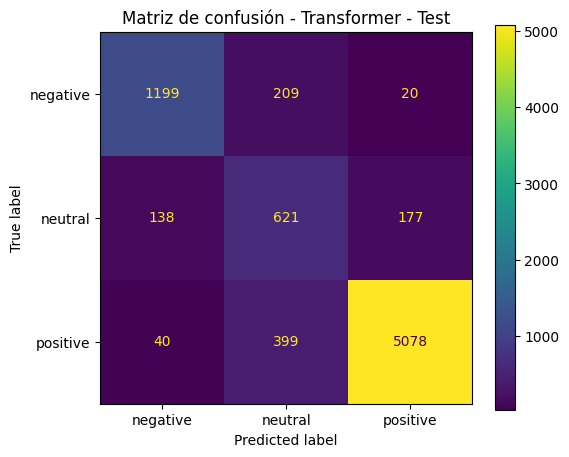

In [17]:
# ============================================================
# 16. Predicciones y matriz de confusión en test
# ============================================================

test_predictions = trainer.predict(tokenized_dataset["test"])

test_logits = test_predictions.predictions
test_true = test_predictions.label_ids
test_pred = np.argmax(test_logits, axis=-1)

test_true_labels = [id2label[int(x)] for x in test_true]
test_pred_labels = [id2label[int(x)] for x in test_pred]

print("Classification report - Transformer Test:")
print(
    classification_report(
        test_true_labels,
        test_pred_labels,
        labels=["negative", "neutral", "positive"],
        target_names=["negative", "neutral", "positive"],
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    test_true_labels,
    test_pred_labels,
    labels=["negative", "neutral", "positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Matriz de confusión - Transformer - Test")
plt.show()

In [18]:
# ============================================================
# 17. Guardar métricas y predicciones
# ============================================================

test_report_dict = classification_report(
    test_true_labels,
    test_pred_labels,
    labels=["negative", "neutral", "positive"],
    target_names=["negative", "neutral", "positive"],
    output_dict=True,
    zero_division=0
)

metrics_output = {
    "model_checkpoint": MODEL_CHECKPOINT,
    "max_length": MAX_LENGTH,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "fast_dev_run": FAST_DEV_RUN,
    "validation_metrics": {
        k: float(v) for k, v in validation_metrics.items()
        if isinstance(v, (int, float, np.integer, np.floating))
    },
    "test_metrics": {
        k: float(v) for k, v in test_metrics.items()
        if isinstance(v, (int, float, np.integer, np.floating))
    },
    "test_classification_report": test_report_dict,
    "test_confusion_matrix": cm.tolist(),
    "label2id": label2id,
    "id2label": id2label,
}

metrics_path = METRICS_DIR / "transformer_sentiment_metrics.json"

with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics_output, f, indent=2, ensure_ascii=False)

test_predictions_df = test_pd.copy()
test_predictions_df["true_label"] = test_true_labels
test_predictions_df["predicted_label"] = test_pred_labels
test_predictions_df["is_correct"] = test_predictions_df["true_label"] == test_predictions_df["predicted_label"]

predictions_path = PREDICTIONS_DIR / "transformer_test_predictions.parquet"
test_predictions_df.to_parquet(predictions_path, index=False)

print("Métricas guardadas en:")
print(metrics_path)

print("\nPredicciones guardadas en:")
print(predictions_path)

Métricas guardadas en:
/content/hidden_gems_ai/outputs/sentiment_review_transformer/metrics/transformer_sentiment_metrics.json

Predicciones guardadas en:
/content/hidden_gems_ai/outputs/sentiment_review_transformer/predictions/transformer_test_predictions.parquet


In [19]:
# ============================================================
# 18. Guardar modelo final
# ============================================================

final_model_path = MODEL_DIR / "best_transformer_sentiment_model"

trainer.save_model(str(final_model_path))
tokenizer.save_pretrained(str(final_model_path))

print("Modelo guardado en:")
print(final_model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en:
/content/hidden_gems_ai/outputs/sentiment_review_transformer/model/best_transformer_sentiment_model


In [20]:
# ============================================================
# 19. Predicciones manuales
# ============================================================

def predict_sentiment_transformer(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    ).to(trainer.model.device)

    trainer.model.eval()

    with torch.no_grad():
        outputs = trainer.model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=-1)

    results = []

    for text, pred_id, prob in zip(texts, preds, probs):
        results.append({
            "text": text,
            "predicted_label": id2label[int(pred_id)],
            "confidence": float(prob[pred_id]),
            "proba_negative": float(prob[label2id["negative"]]),
            "proba_neutral": float(prob[label2id["neutral"]]),
            "proba_positive": float(prob[label2id["positive"]]),
        })

    return pd.DataFrame(results)


manual_examples = [
    "The burger was amazing, juicy and perfectly cooked.",
    "The food was okay, nothing special, but the service was fine.",
    "The pizza was cold, dry and honestly disappointing.",
    "Great atmosphere, but the pasta was bland and overpriced.",
    "I loved the tacos and the homemade salsa was fantastic.",
    "The service was terrible, but the pasta was delicious.",
    "The ribs were good, although the place was too noisy and expensive."
]

manual_results = predict_sentiment_transformer(manual_examples)

display(manual_results)

,text,predicted_label,confidence,proba_negative,proba_neutral,proba_positive
0,"The burger was amazing, juicy and perfectly cooked.",positive,0.993171,0.000609,0.006219,0.993171
1,"The food was okay, nothing special, but the service was fine.",neutral,0.952827,0.038946,0.952827,0.008227
2,"The pizza was cold, dry and honestly disappointing.",negative,0.989130,0.989130,0.010182,0.000688
3,"Great atmosphere, but the pasta was bland and overpriced.",neutral,0.611007,0.379939,0.611007,0.009054
4,I loved the tacos and the homemade salsa was fantastic.,positive,0.990129,0.000627,0.009244,0.990129
5,"The service was terrible, but the pasta was delicious.",neutral,0.817450,0.088980,0.817450,0.093570
6,"The ribs were good, although the place was too noisy and expensive.",neutral,0.957576,0.010432,0.957576,0.031992


,model,test_accuracy,test_macro_f1,test_weighted_f1
0,Majority Baseline,0.700038,0.274519,0.576520
1,TF-IDF + Logistic Regression,0.867022,0.717788,0.851811
2,TF-IDF + Logistic Regression Balanced,0.806624,0.720362,0.829082
3,DistilBERT Transformer Weighted,0.875270,0.789880,0.881820


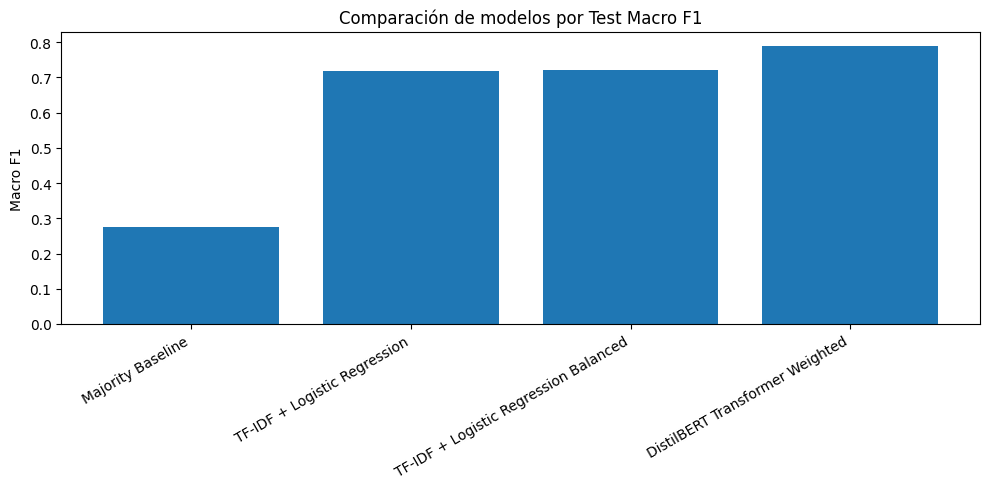

In [21]:
# ============================================================
# 20. Comparación final clásico vs transformer
# ============================================================

comparison_rows = [
    {
        "model": "Majority Baseline",
        "test_accuracy": 0.7000380662352493,
        "test_macro_f1": 0.27451858486341246,
        "test_weighted_f1": 0.5765203778802613,
    },
    {
        "model": "TF-IDF + Logistic Regression",
        "test_accuracy": 0.8670219515289938,
        "test_macro_f1": 0.7177875678762594,
        "test_weighted_f1": 0.8518105840452578,
    },
    {
        "model": "TF-IDF + Logistic Regression Balanced",
        "test_accuracy": 0.8066235249333841,
        "test_macro_f1": 0.7203622664503184,
        "test_weighted_f1": 0.8290823239257551,
    },
    {
        "model": "DistilBERT Transformer Weighted",
        "test_accuracy": test_metrics["eval_accuracy"],
        "test_macro_f1": test_metrics["eval_macro_f1"],
        "test_weighted_f1": test_metrics["eval_weighted_f1"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["model"], comparison_df["test_macro_f1"])
plt.title("Comparación de modelos por Test Macro F1")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 21. Análisis de errores del transformer
# ============================================================

transformer_errors_df = test_predictions_df.copy()

error_summary = (
    transformer_errors_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["true_label", "count"], ascending=[True, False])
)

display(error_summary)

only_errors = transformer_errors_df[~transformer_errors_df["is_correct"]].copy()

print("Total ejemplos test:", len(transformer_errors_df))
print("Total errores:", len(only_errors))
print("Porcentaje de error:", round(len(only_errors) / len(transformer_errors_df) * 100, 2), "%")

error_type_summary = (
    only_errors
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_type_summary)

,true_label,predicted_label,count
0,negative,negative,1199
1,negative,neutral,209
2,negative,positive,20
4,neutral,neutral,621
5,neutral,positive,177
3,neutral,negative,138
8,positive,positive,5078
7,positive,neutral,399
6,positive,negative,40


Total ejemplos test: 7881
Total errores: 983
Porcentaje de error: 12.47 %


,true_label,predicted_label,count
5,positive,neutral,399
0,negative,neutral,209
3,neutral,positive,177
2,neutral,negative,138
4,positive,negative,40
1,negative,positive,20


In [23]:
# ============================================================
# 22. Ejemplos de errores del transformer
# ============================================================

def show_transformer_error_examples(errors_df, true_label, predicted_label, n=5, max_chars=1200):
    subset = errors_df[
        (errors_df["true_label"] == true_label)
        & (errors_df["predicted_label"] == predicted_label)
    ].copy()

    print("=" * 100)
    print(f"TRUE = {true_label} | PRED = {predicted_label} | total = {len(subset)}")
    print("=" * 100)

    if subset.empty:
        print("No hay ejemplos para este tipo de error.")
        return

    sample = subset.sample(
        n=min(n, len(subset)),
        random_state=RANDOM_STATE
    )

    for i, row in enumerate(sample.itertuples(), start=1):
        print(f"\nEjemplo {i}")
        print(f"Rating: {getattr(row, 'rating_value', None)}")
        print(f"Real: {row.true_label}")
        print(f"Predicho: {row.predicted_label}")
        print(f"Texto:\n{row.model_text[:max_chars]}")
        print("-" * 100)


show_transformer_error_examples(transformer_errors_df, "neutral", "positive", n=5)
show_transformer_error_examples(transformer_errors_df, "neutral", "negative", n=5)
show_transformer_error_examples(transformer_errors_df, "positive", "neutral", n=5)
show_transformer_error_examples(transformer_errors_df, "negative", "neutral", n=5)

TRUE = neutral | PRED = positive | total = 177

Ejemplo 1
Rating: 3.0
Real: neutral
Predicho: positive
Texto:
Pei Wei is the American version of the Asian cuisine. There dishes are made to order in an open concept kitchen. The food and servive is always good. I love the quick atmosphere. Keep in mind It's not a full service restaurant. I recommend there Mango california roll and there crab wontons. On there main dishes they offer two different sizes. Make sure you let them know if you want the small or regular because if you don't most likely the will give you the regular and trust me it's a nice portion. We have eaten here many times and always enjoyed it.
----------------------------------------------------------------------------------------------------

Ejemplo 2
Rating: 3.0
Real: neutral
Predicho: positive
Texto:
First time here . Great smoothies!!! Well done too. They have a great variety of smoothies. I think this is a place I'd comeback and we'll make me a smoothie fanatic. The

In [24]:
# ============================================================
# 23. Guardar comparación y resumen de errores
# ============================================================

comparison_path = METRICS_DIR / "model_comparison_classic_vs_transformer.json"
error_summary_path = METRICS_DIR / "transformer_error_summary.json"

comparison_output = {
    "models": comparison_df.to_dict(orient="records"),
    "best_model_by_macro_f1": comparison_df.sort_values("test_macro_f1", ascending=False).iloc[0].to_dict(),
}

with comparison_path.open("w", encoding="utf-8") as f:
    json.dump(comparison_output, f, indent=2, ensure_ascii=False)

transformer_error_summary = {
    "model": MODEL_CHECKPOINT,
    "test_total": int(len(transformer_errors_df)),
    "test_correct": int(transformer_errors_df["is_correct"].sum()),
    "test_errors": int((~transformer_errors_df["is_correct"]).sum()),
    "test_accuracy": float(transformer_errors_df["is_correct"].mean()),
    "error_types": [
        {
            "true_label": str(row.true_label),
            "predicted_label": str(row.predicted_label),
            "count": int(row.count),
        }
        for row in error_type_summary.itertuples(index=False)
    ],
}

with error_summary_path.open("w", encoding="utf-8") as f:
    json.dump(transformer_error_summary, f, indent=2, ensure_ascii=False)

print("Comparación guardada en:")
print(comparison_path)

print("\nResumen de errores guardado en:")
print(error_summary_path)

Comparación guardada en:
/content/hidden_gems_ai/outputs/sentiment_review_transformer/metrics/model_comparison_classic_vs_transformer.json

Resumen de errores guardado en:
/content/hidden_gems_ai/outputs/sentiment_review_transformer/metrics/transformer_error_summary.json


## Conclusión del Notebook 03

En este notebook se ha entrenado un modelo transformer `distilbert-base-uncased` para clasificación de sentimiento general sobre reviews gastronómicas de Yelp.

El transformer mejora al mejor modelo clásico del Notebook 01. Aunque la mejora en accuracy es moderada, la mejora en Macro F1 es notable, lo que indica un mejor comportamiento global entre clases y una mayor capacidad para tratar la clase minoritaria `neutral`.

El modelo clásico TF-IDF + Regresión Logística obtuvo en test:

- Accuracy: 0.8670
- Macro F1: 0.7178
- Weighted F1: 0.8518

El transformer obtuvo en test:

- Accuracy: 0.8753
- Macro F1: 0.7899
- Weighted F1: 0.8818

La clase `neutral` sigue siendo la más compleja, pero mejora de forma importante respecto al modelo clásico. Esto confirma que el transformer capta mejor el contexto textual y las reseñas mixtas.

Aun así, este modelo debe interpretarse como un clasificador de sentimiento general de review. Para Hidden Gems, el objetivo final no es solo saber si una reseña es positiva o negativa, sino detectar el sentimiento asociado a platos concretos.

Por tanto, este modelo se considera un módulo auxiliar útil y una referencia fuerte para fases posteriores. El siguiente gran paso del proyecto será avanzar hacia la detección de menciones de platos y, posteriormente, hacia el sentimiento por mención.